# Extraction de la trajectoire globale

## Description

La trajectoire globale est obtenue a partir des centres successifs estimes de la voiture. Chaque centre correspond a la position estimee de l'objet dans une frame. Relier ces centres permet de visualiser le trajet global de la voiture directement dans la scene.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)
Fichier de trajectoire utilise: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\trajectory.csv
Nombre total de centres utilises: 120
Frame de debut: 0
Frame de fin: 119
min/max x: 625.50 / 654
min/max y: 359.50 / 368.50
Apercu des centres successifs estimes:


,frame,x,y,bbox_x,bbox_y,bbox_w,bbox_h
0,0,641.0,359.5,542,314,198,91
1,1,641.0,359.5,542,314,198,91
2,2,641.0,359.5,542,314,198,91
3,3,640.0,367.0,541,329,198,76
4,4,640.0,367.0,541,329,198,76
5,5,639.0,367.0,540,329,198,76
6,6,638.0,367.0,539,329,198,76
7,7,638.0,367.0,539,329,198,76
8,8,637.0,367.0,538,329,198,76
9,9,636.0,367.0,537,329,198,76


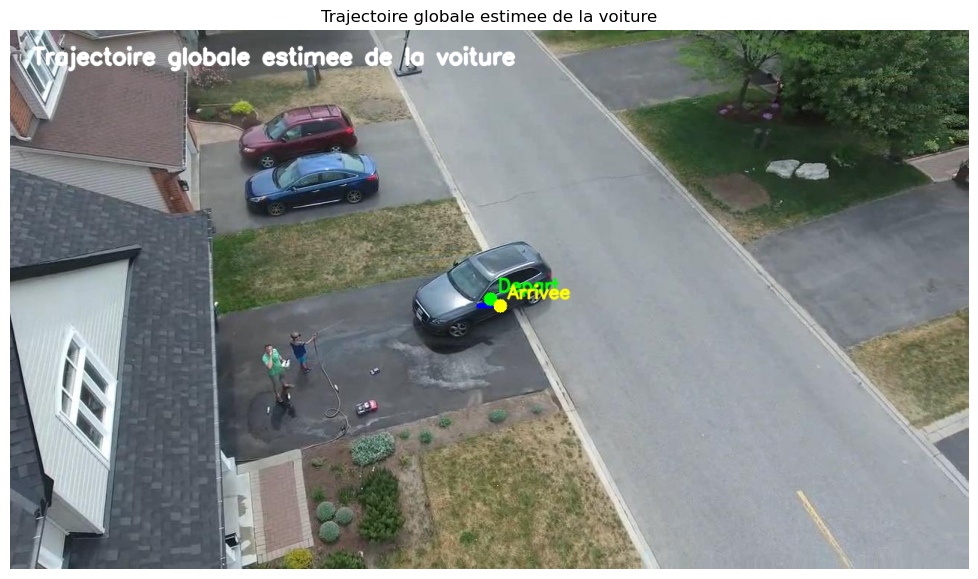

Trajectoire globale sauvegardee: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\trajectory\trajectory_global_overlay.png


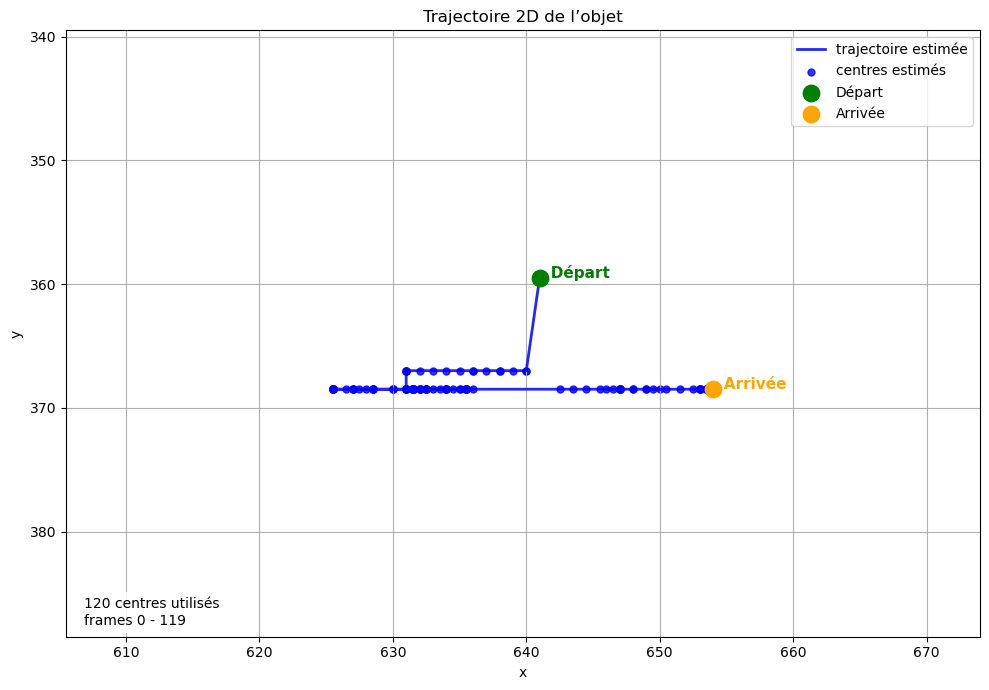

Trajectoire 2D corrigee sauvegardee: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\trajectory\trajectory_2d_plot.png


In [1]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # bbox manuelle: x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

def clean_trajectory_centers(df):
    required = {"frame", "x", "y"}
    missing = required.difference(df.columns)
    if missing:
        raise RuntimeError(f"Colonnes manquantes pour la trajectoire 2D: {missing}")

    trajectory_df = df[["frame", "x", "y"]].copy()
    for column in ["frame", "x", "y"]:
        trajectory_df[column] = pd.to_numeric(trajectory_df[column], errors="coerce")
    trajectory_df = trajectory_df.replace([np.inf, -np.inf], np.nan)
    trajectory_df = trajectory_df.dropna(subset=["frame", "x", "y"])
    trajectory_df = trajectory_df.sort_values("frame", kind="mergesort").reset_index(drop=True)
    return trajectory_df


def trajectory_candidate_paths():
    priority_paths = [
        RESULTS_DIR / "trajectory.csv",
        RESULTS_DIR / "trajectory" / "trajectory.csv",
    ]
    other_paths = []
    if RESULTS_DIR.exists():
        for path in sorted(RESULTS_DIR.rglob("*.csv")):
            path_text = str(path).lower()
            if "groundtruth" in path_text:
                continue
            if path in priority_paths:
                continue
            other_paths.append(path)
    return priority_paths + other_paths


def read_trajectory_candidate(path):
    if not path.exists() or "groundtruth" in str(path).lower():
        return None
    try:
        df = pd.read_csv(path)
    except Exception:
        return None
    if not {"frame", "x", "y"}.issubset(df.columns):
        return None
    trajectory_df = clean_trajectory_centers(df)
    if trajectory_df.empty:
        return None
    return {"path": path, "df": df, "trajectory_df": trajectory_df}


def ensure_tracking_table():
    candidates = []
    for path in trajectory_candidate_paths():
        candidate = read_trajectory_candidate(path)
        if candidate is not None:
            candidates.append(candidate)

    if not candidates:
        raise FileNotFoundError(
            "Aucun CSV de resultats contenant frame, x et y n'a ete trouve. "
            "Lancez d'abord le pipeline principal pour produire la trajectoire."
        )

    max_centers = max(len(candidate["trajectory_df"]) for candidate in candidates)
    priority_paths = [RESULTS_DIR / "trajectory.csv", RESULTS_DIR / "trajectory" / "trajectory.csv"]
    for priority_path in priority_paths:
        for candidate in candidates:
            if candidate["path"] == priority_path and len(candidate["trajectory_df"]) == max_centers:
                return candidate["df"], candidate["trajectory_df"], candidate["path"]

    best_candidate = max(candidates, key=lambda candidate: len(candidate["trajectory_df"]))
    return best_candidate["df"], best_candidate["trajectory_df"], best_candidate["path"]


def format_stat_value(value):
    value = float(value)
    if value.is_integer():
        return str(int(value))
    return f"{value:.2f}"


def print_trajectory_summary(trajectory_df, source_path):
    frame_values = trajectory_df["frame"].to_numpy(dtype=float)
    x_values = trajectory_df["x"].to_numpy(dtype=float)
    y_values = trajectory_df["y"].to_numpy(dtype=float)

    print("Fichier de trajectoire utilise:", source_path)
    print(f"Nombre total de centres utilises: {len(trajectory_df)}")
    print(f"Frame de debut: {format_stat_value(frame_values[0])}")
    print(f"Frame de fin: {format_stat_value(frame_values[-1])}")
    print(f"min/max x: {format_stat_value(np.min(x_values))} / {format_stat_value(np.max(x_values))}")
    print(f"min/max y: {format_stat_value(np.min(y_values))} / {format_stat_value(np.max(y_values))}")

def make_trajectory_overlay(df, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    frame_index = int(df["frame"].iloc[min(len(df) // 2, len(df) - 1)])
    frame_index = max(0, min(frame_index, len(image_files) - 1))
    background = cv2.imread(str(image_files[frame_index]))
    if background is None:
        background = cv2.imread(str(image_files[0]))
    overlay = background.copy()
    points = df[["x", "y"]].dropna().to_numpy(dtype=np.int32)
    if len(points) == 0:
        raise RuntimeError("Aucun centre disponible pour dessiner la trajectoire.")
    for i in range(1, len(points)):
        cv2.line(overlay, tuple(points[i - 1]), tuple(points[i]), (0, 0, 255), 2)
    step = max(1, len(points) // 180)
    for point in points[::step]:
        cv2.circle(overlay, tuple(point), 3, (255, 0, 0), -1)
    start = tuple(points[0])
    end = tuple(points[-1])
    cv2.circle(overlay, start, 9, (0, 255, 0), -1)
    cv2.circle(overlay, end, 9, (0, 255, 255), -1)
    cv2.putText(overlay, "Depart", (start[0] + 10, start[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2, cv2.LINE_AA)
    cv2.putText(overlay, "Arrivee", (end[0] + 10, end[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 255), 2, cv2.LINE_AA)
    cv2.putText(overlay, "Trajectoire globale estimee de la voiture", (30, 45), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 3, cv2.LINE_AA)
    cv2.imwrite(str(output_path), overlay)
    return output_path, overlay

def make_trajectory_2d_plot(trajectory_df, output_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    trajectory_df = clean_trajectory_centers(trajectory_df)
    if trajectory_df.empty:
        raise RuntimeError("Aucun centre valide pour tracer la trajectoire 2D.")

    x_values = trajectory_df["x"].to_numpy(dtype=float)
    y_values = trajectory_df["y"].to_numpy(dtype=float)
    frame_values = trajectory_df["frame"].to_numpy(dtype=float)

    min_x, max_x = float(np.min(x_values)), float(np.max(x_values))
    min_y, max_y = float(np.min(y_values)), float(np.max(y_values))
    margin = 20

    plt.figure(figsize=(10, 7))
    plt.plot(x_values, y_values, color="blue", linewidth=2, alpha=0.85, label="trajectoire estim\u00e9e")
    plt.scatter(x_values, y_values, color="blue", s=25, alpha=0.8, label="centres estim\u00e9s")
    plt.scatter(x_values[0], y_values[0], color="green", s=140, label="D\u00e9part", zorder=5)
    plt.scatter(x_values[-1], y_values[-1], color="orange", s=140, label="Arriv\u00e9e", zorder=5)
    plt.text(x_values[0], y_values[0], "  D\u00e9part", color="green", fontsize=11, weight="bold")
    plt.text(x_values[-1], y_values[-1], "  Arriv\u00e9e", color="orange", fontsize=11, weight="bold")
    plt.title("Trajectoire 2D de l\u2019objet")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.legend()
    plt.gca().invert_yaxis()
    plt.xlim(min_x - margin, max_x + margin)
    plt.ylim(max_y + margin, min_y - margin)
    plt.text(
        0.02,
        0.02,
        f"{len(trajectory_df)} centres utilis\u00e9s\nframes {format_stat_value(frame_values[0])} - {format_stat_value(frame_values[-1])}",
        transform=plt.gca().transAxes,
        fontsize=10,
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"),
    )
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    return output_path


def make_speed_direction_graphs(df):
    graphs_dir = ensure_dir(RESULTS_DIR / "graphs")
    speed_path = graphs_dir / "speed_over_time.png"
    direction_path = graphs_dir / "direction_over_time.png"
    pos_path = graphs_dir / "positions_over_time.png"

    plt.figure(figsize=(11, 5))
    plt.plot(df["frame"], df["speed_px_per_frame"], color="tab:blue", linewidth=2)
    plt.title("Vitesse de la voiture")
    plt.xlabel("frames")
    plt.ylabel("vitesse (pixels/frame)")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(speed_path, dpi=150)
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df["frame"], df["direction_deg"], color="tab:green", linewidth=2)
    plt.title("Direction du mouvement")
    plt.xlabel("frames")
    plt.ylabel("direction (degres)")
    plt.grid(True, alpha=0.35)
    plt.tight_layout()
    plt.savefig(direction_path, dpi=150)
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df["frame"], df["x"], label="x(t)", linewidth=2)
    plt.plot(df["frame"], df["y"], label="y(t)", linewidth=2)
    plt.title("Positions du centre estime")
    plt.xlabel("frames")
    plt.ylabel("position (pixels)")
    plt.grid(True, alpha=0.35)
    plt.legend()
    plt.tight_layout()
    plt.savefig(pos_path, dpi=150)
    plt.show()
    return speed_path, direction_path, pos_path

trajectory_dir = ensure_dir(RESULTS_DIR / "trajectory")
df, trajectory_df, trajectory_source = ensure_tracking_table()
print_trajectory_summary(trajectory_df, trajectory_source)
print("Apercu des centres successifs estimes:")
display_columns = [column for column in ["frame", "x", "y", "bbox_x", "bbox_y", "bbox_w", "bbox_h"] if column in df.columns]
display(df[display_columns].head(12))

trajectory_path, overlay = make_trajectory_overlay(trajectory_df, trajectory_dir / "trajectory_global_overlay.png")
show_bgr(overlay, "Trajectoire globale estimee de la voiture", figsize=(13, 7))
print("Trajectoire globale sauvegardee:", trajectory_path)

trajectory_2d_path = make_trajectory_2d_plot(trajectory_df, trajectory_dir / "trajectory_2d_plot.png")
print("Trajectoire 2D corrigee sauvegardee:", trajectory_2d_path)


## Interpretation

La trajectoire 2D est construite à partir de toutes les positions successives estimées de la voiture. Les points sont reliés dans l'ordre temporel pour représenter le déplacement global de l'objet dans le plan image. Le point vert indique le début du suivi et le point orange indique la fin du déplacement. Cette visualisation complète l'overlay sur l'image originale et permet une lecture géométrique plus claire du trajet.

La trajectoire globale superposée à une frame originale reste une vue complémentaire pour replacer ce trajet dans la scène.


## Resume de l'etape

Une seule trajectoire globale finale a ete produite et affichee sur une frame originale. Elle constitue la synthese spatiale du deplacement de la voiture et fournit la base pour l'analyse de vitesse et de direction.
